In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
data = pd.read_csv("advertising.csv")

In [19]:
data.info()               

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Daily Time Spent on Site  1000 non-null   float64       
 1   Age                       1000 non-null   int64         
 2   Area Income               1000 non-null   float64       
 3   Daily Internet Usage      1000 non-null   float64       
 4   Ad Topic Line             1000 non-null   object        
 5   City                      1000 non-null   object        
 6   Male                      1000 non-null   int64         
 7   Country                   1000 non-null   object        
 8   Timestamp                 1000 non-null   datetime64[ns]
 9   Clicked on Ad             1000 non-null   int64         
 10  Hour                      1000 non-null   int32         
 11  Month                     1000 non-null   int32         
 12  DayOfWeek            

In [17]:
data.describe

<bound method NDFrame.describe of      Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                       68.95   35     61833.90                256.09   
1                       80.23   31     68441.85                193.77   
2                       69.47   26     59785.94                236.50   
3                       74.15   29     54806.18                245.89   
4                       68.37   35     73889.99                225.58   
..                        ...  ...          ...                   ...   
995                     72.97   30     71384.57                208.58   
996                     51.30   45     67782.17                134.42   
997                     51.63   51     42415.72                120.37   
998                     55.55   19     41920.79                187.95   
999                     45.01   26     29875.80                178.35   

                             Ad Topic Line            City  Male  \
0       Cloned 5thgen

In [6]:
data.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

In [18]:
data['Clicked on Ad'].value_counts()

Clicked on Ad
0    500
1    500
Name: count, dtype: int64

## Histogram

A histogram is a plot used mainly for **numerical features**.

It shows the **distribution of numerical values** by grouping them into ranges (bins).

### Symmetric Distribution

A distribution is **symmetric** when the values are spread in a similar way on both sides of the center.

### Skewed Distribution

A distribution is **skewed** when the values are not evenly distributed and one side has a **longer tail**.

* **Right-skewed:** longer tail toward larger values.
* **Left-skewed:** longer tail toward smaller values.

### Why does it matter?

* **Symmetric data:** Generally has a balanced distribution and usually does not require special treatment just because of its shape.
* **Skewed data:** Indicates that some values are concentrated more toward one side. Strong skewness can affect some statistical methods and may sometimes require transformations or other preprocessing.

### What can we learn from a histogram?

It helps us understand:

* Where most values are concentrated
* How the values are spread
* Whether the distribution is **symmetric or skewed**
* Whether there are any unusual or extreme values

**In short:**

> Histogram → used mainly for numerical features → helps us understand the distribution and shape of the data.


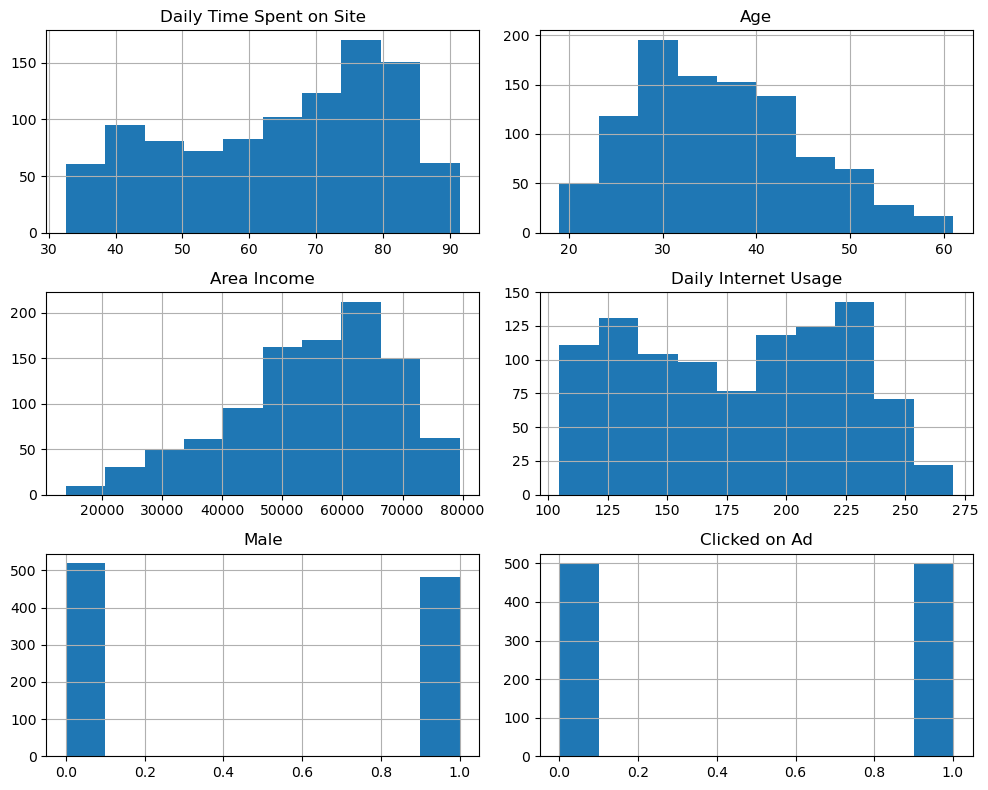

In [8]:
data.hist(figsize = (10,8))
plt.tight_layout()
plt.show()

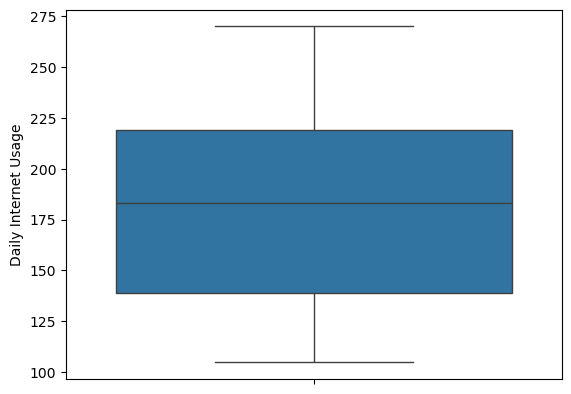

In [20]:
sns.boxplot(y=data['Daily Internet Usage'])
plt.show()

<Axes: xlabel='Clicked on Ad', ylabel='Daily Time Spent on Site'>

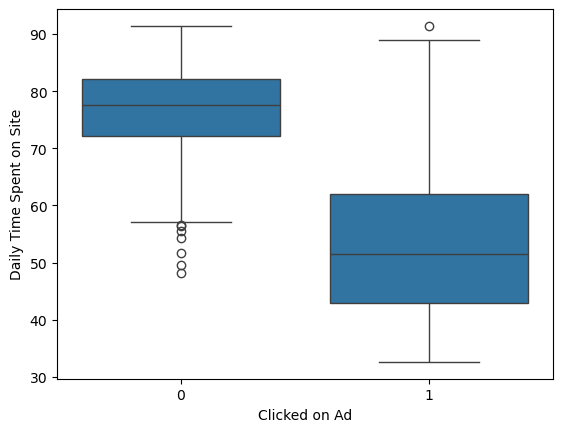

In [10]:
sns.boxplot(data=data, x='Clicked on Ad', y='Daily Time Spent on Site')

<Axes: xlabel='Clicked on Ad', ylabel='Age'>

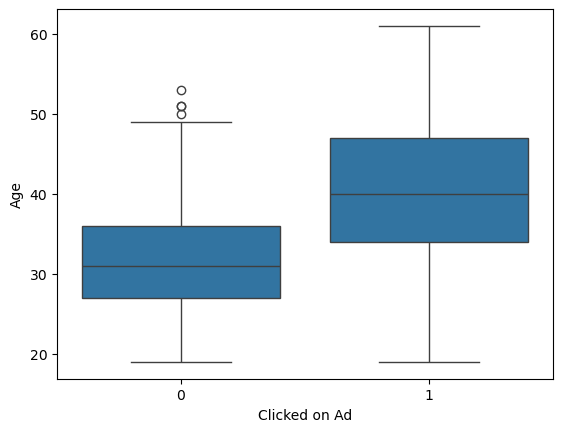

In [11]:
sns.boxplot(data=data, x='Clicked on Ad', y='Age')

<Axes: xlabel='Clicked on Ad', ylabel='Area Income'>

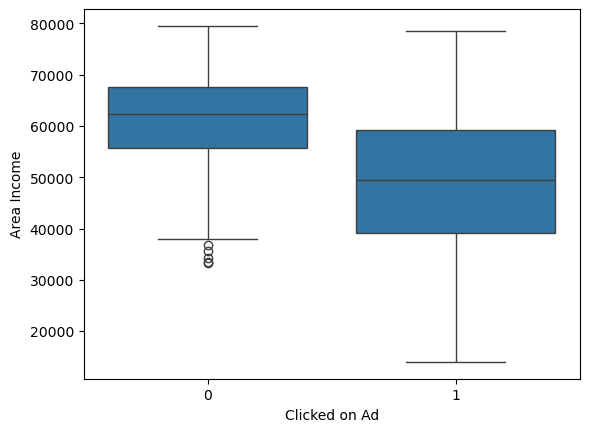

In [12]:
sns.boxplot(data=data, x='Clicked on Ad', y='Area Income')

<Axes: xlabel='Clicked on Ad', ylabel='Daily Internet Usage'>

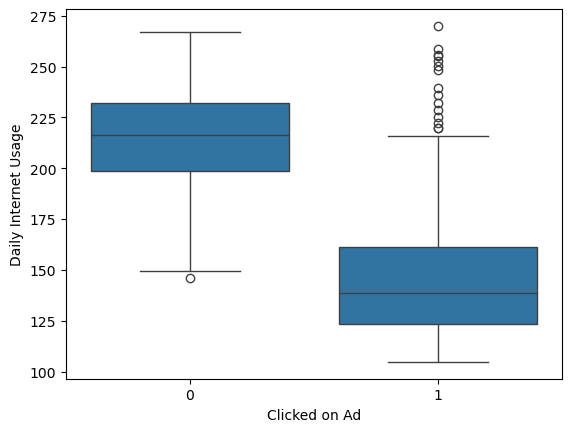

In [13]:
sns.boxplot(data=data, x='Clicked on Ad', y='Daily Internet Usage')

<Axes: >

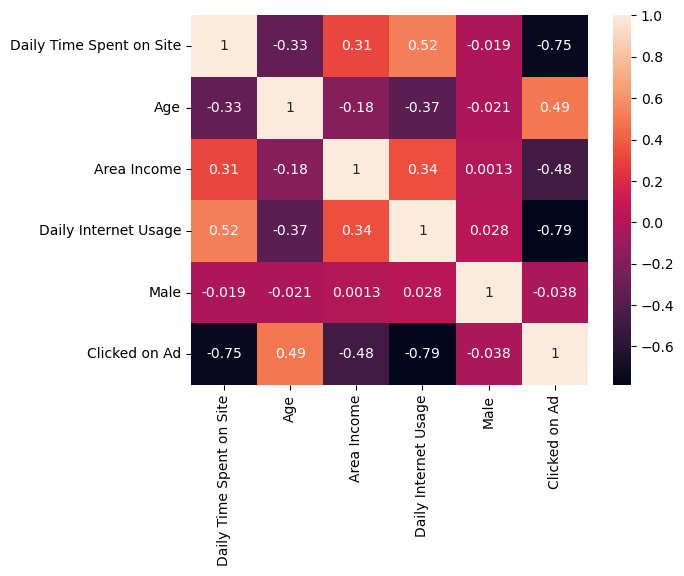

In [15]:
numeric_data = data.select_dtypes(include ='number')
sns.heatmap(data=numeric_data.corr(), annot = True)

<Axes: xlabel='Male', ylabel='count'>

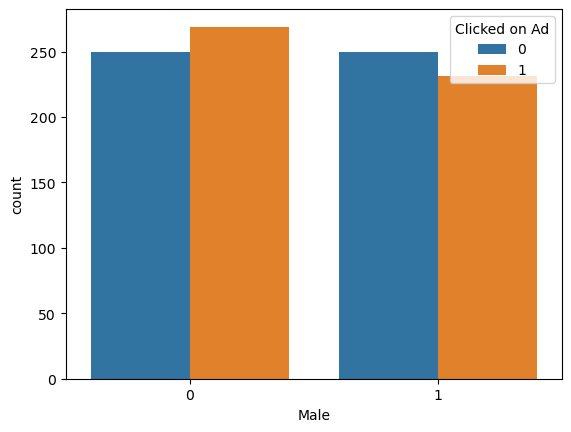

In [16]:
sns.countplot(data = data , x= 'Male', hue='Clicked on Ad')

In [22]:
data['Ad Topic Line'].nunique()

1000

In [6]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

In [7]:
data['Hour'] = data['Timestamp'].dt.hour

In [8]:
data['Month'] = data['Timestamp'].dt.month

In [9]:
data['DayOfWeek'] = data['Timestamp'].dt.dayofweek

<Axes: xlabel='Month', ylabel='count'>

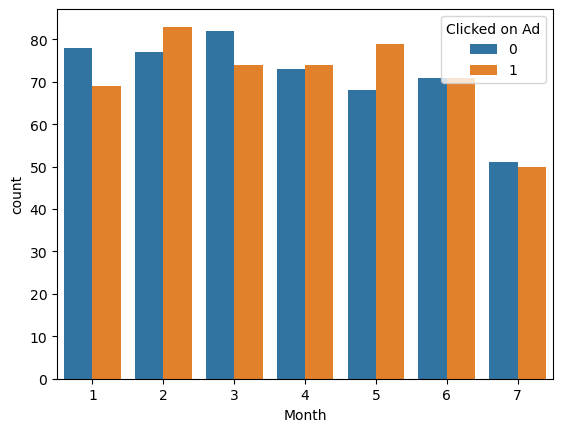

In [12]:
sns.countplot(data = data, x ='Month', hue ='Clicked on Ad')

<Axes: xlabel='DayOfWeek', ylabel='count'>

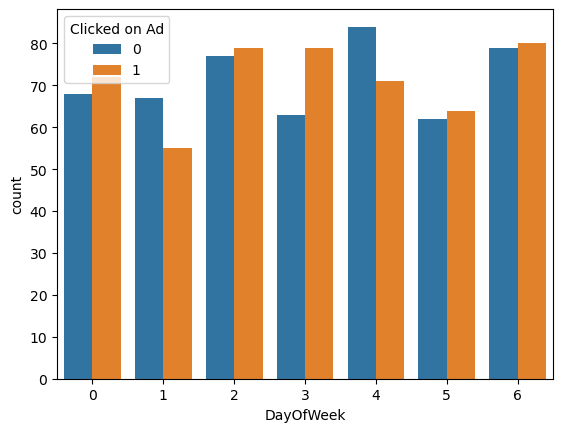

In [13]:
sns.countplot(data = data, x ='DayOfWeek', hue ='Clicked on Ad')

<Axes: xlabel='Hour', ylabel='count'>

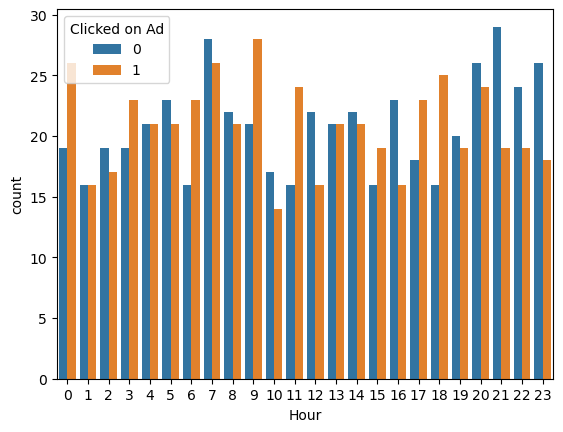

In [14]:
sns.countplot(data = data, x ='Hour', hue ='Clicked on Ad')

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [33]:
X = data[['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Male']]
y = data['Clicked on Ad']

In [34]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state =42)

In [35]:
model = LogisticRegression()

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

In [38]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = model.predict(X_test_scaled)

In [45]:
from sklearn.metrics import confusion_matrix, classification_report

In [46]:
cm = confusion_matrix(y_pred,y_test)

In [43]:
print(cm)

[[143   6]
 [  3 148]]


In [47]:
cf = classification_report(y_pred,y_test)

In [48]:
print(cf)

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       149
           1       0.96      0.98      0.97       151

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



# `predict_proba()` in Logistic Regression

## What is `predict_proba()`?

`predict_proba()` gives the **probability of each class** for every sample.

For example:

```text
[[0.80, 0.20],
 [0.30, 0.70],
 [0.10, 0.90]]
```

Each row represents one sample:

* First value → probability of **Class 0**
* Second value → probability of **Class 1**

The probabilities always add up to **1**.

---

## Why do we need probabilities?

`predict()` directly gives the final class:

```text
0 or 1
```

It normally uses a **0.5 threshold**.

But for the **ROC curve**, we need to test different thresholds:

```text
0.5 → 0.6 → 0.7 → 0.8 → ...
```

To do this, we need the **probability values**.

For example:

```text
Probability = 0.80
```

At threshold `0.5` → predict `1`

At threshold `0.9` → predict `0`

Therefore:

> **ROC needs probability values so that we can change the classification threshold and calculate TPR and FPR at different thresholds.**

---

# Why do we take only Class 1 probability?

Our target is:

```text
Clicked on Ad
```

It has two classes:

```text
0 → Did not click
1 → Clicked
```

For ROC, we choose **Class 1 as the positive class**.

Therefore, we need the probability that:

> **The person belongs to Class 1 (clicked on the ad).**

We don't need both probabilities because:

```text
P(Class 0) + P(Class 1) = 1
```

So if:

```text
P(Class 1) = 0.80
```

then automatically:

```text
P(Class 0) = 0.20
```

---

## What does `[:, 1]` mean?

`predict_proba()` returns two columns:

```text
Column 0 → Class 0 probability
Column 1 → Class 1 probability
```

Python uses zero-based indexing.

Therefore:

```python
[:, 1]
```

means:

> **Take every row (`:`) and select column 1.**

So:

```python
model.predict_proba(X_test_scaled)[:, 1]
```

means:

> **Get the probability of Class 1 (Clicked on Ad) for every test sample.**

---

In [49]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [50]:
from sklearn.metrics import roc_curve

In [52]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

In [53]:
print(thresholds)
print(fpr)
print(tpr)

[       inf 0.99999118 0.9557522  0.93268842 0.88416942 0.86536704
 0.52640527 0.23965592 0.2363373  0.18755367 0.17586576 0.14567867
 0.14020056 0.0485453  0.04564879 0.00936091 0.00926742 0.00712661
 0.00706391 0.00288313]
[0.         0.         0.         0.00684932 0.00684932 0.01369863
 0.01369863 0.06164384 0.06164384 0.0890411  0.0890411  0.10273973
 0.10273973 0.23972603 0.23972603 0.69178082 0.69178082 0.7739726
 0.7739726  1.        ]
[0.         0.00649351 0.85064935 0.85064935 0.87012987 0.87012987
 0.96103896 0.96103896 0.96753247 0.96753247 0.97402597 0.97402597
 0.98051948 0.98051948 0.98701299 0.98701299 0.99350649 0.99350649
 1.         1.        ]


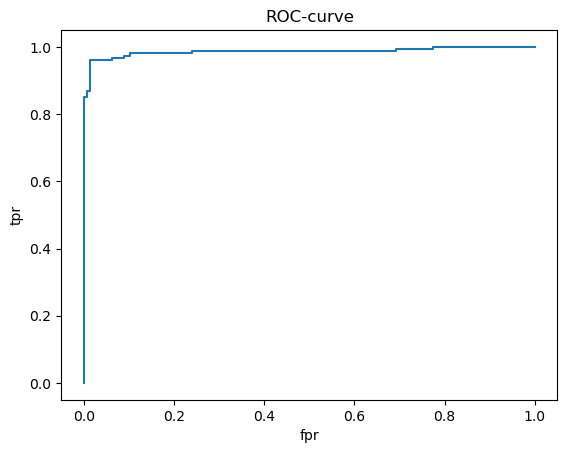

In [58]:
plt.plot(fpr,tpr)
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("ROC-curve")
plt.show()

In [59]:
from sklearn.metrics import auc

In [60]:
auc_curve = auc(fpr,tpr)

In [61]:
print(auc_curve)

0.9859010852161538


In [62]:
print(model.coef_)

[[-2.48246979  1.26612437 -1.57987416 -2.61316327 -0.34822004]]


In [63]:
print(model.intercept_)

[1.3876018]
